In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import mapclassify
from shapely import Polygon
import shapely
import contextily
from shapely.geometry import box
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

In [2]:
NOTEBOOK_PATH = Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / 'data'
MAP_DIRECTORY = NOTEBOOK_PATH / "maps"
MAP_DIRECTORY.mkdir(exist_ok=True)

In [3]:
# Fetching data
url = "https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=mobile/year=2022/quarter=1/2022-01-01_performance_mobile_tiles.parquet"
# a local copy of data is stored here
local_path = Path(DATA_DIRECTORY / "internet-speeds.parquet")
if local_path.exists():
    net_speed = gpd.read_parquet(local_path)
else:
    df = pd.read_parquet(url)

    tile_geometries = shapely.from_wkt(df["tile"])
    tile_centroids = shapely.centroid(tile_geometries)
    net_speed = gpd.GeoDataFrame(df, geometry=tile_centroids, crs='EPSG:4326')
    net_speed.to_parquet(local_path)
net_speed.head()
print(f"There are {len(net_speed)} records in our dataset")

There are 3820724 records in our dataset


In [4]:
net_speed.head()

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices,geometry
0,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,19110,7891,77,NaN,NaN,3,2,POINT (-160.02411 70.64268)
1,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,21870,11875,83,NaN,NaN,2,1,POINT (-160.04059 70.63539)
2,0022133222330032,"POLYGON((-160.037841796875 70.6363054807905, -...",-160.0351,70.6354,14567,14691,75,NaN,NaN,9,2,POINT (-160.0351 70.63539)
3,0022133222330100,"POLYGON((-160.02685546875 70.6417687358462, -1...",-160.0241,70.6409,5468,9886,83,NaN,NaN,1,1,POINT (-160.02411 70.64086)
4,0022133222330102,"POLYGON((-160.02685546875 70.6399478155463, -1...",-160.0241,70.6390,24311,16243,72,NaN,NaN,1,1,POINT (-160.02411 70.63904)


<Axes: >

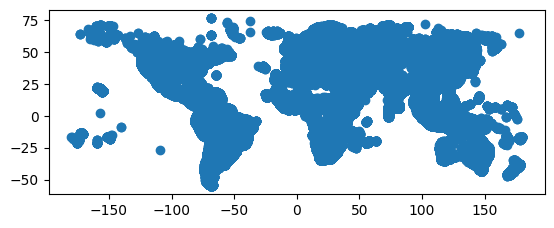

In [15]:
net_speed.plot()

In [4]:
world = gpd.read_file(DATA_DIRECTORY / "ne_110m_admin_0_countries")
europe_shapes = world[world['CONTINENT'] == 'Europe'].copy()

# Standard Europe bounding box
europe_bbox = box(-25, 34, 45, 72)

europe_shapes = europe_shapes.clip(europe_bbox)

<Axes: >

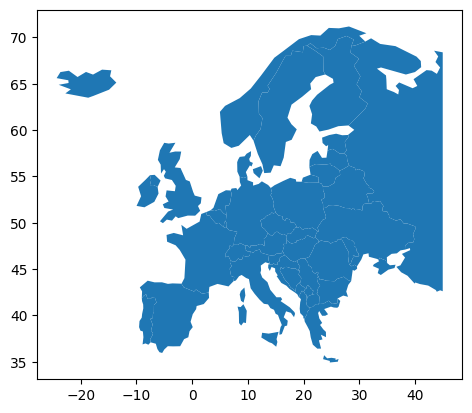

In [12]:
europe_shapes.plot()

In [5]:
net_speed_gdf = gpd.GeoDataFrame(net_speed, geometry='geometry', crs='EPSG:4326')

# Spatial join — keeps only points within European country polygons
europe = gpd.sjoin(net_speed_gdf, europe_shapes[['geometry']], how='inner', predicate='within')

<Axes: >

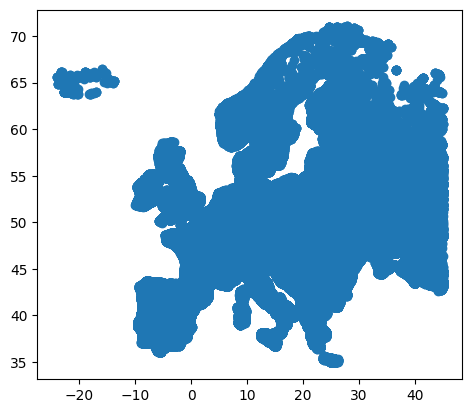

In [14]:
europe.plot()

<Axes: >

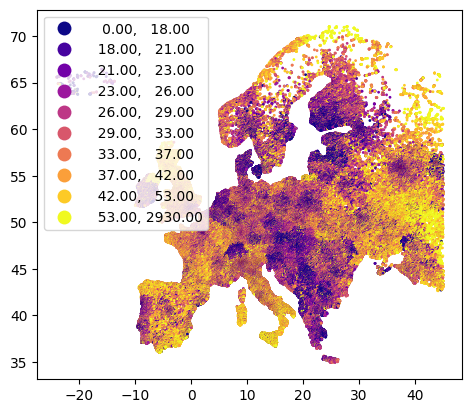

In [18]:
europe.plot(column="avg_lat_ms", cmap="plasma", markersize=1, scheme="Quantiles", k = 10, legend=True)

In [6]:
def assign_hexagon(row, resolution=4):
    return h3.latlng_to_cell(row.geometry.y, row.geometry.x, resolution)

europe['hex_id'] = europe.apply(assign_hexagon, axis=1)

# Average avg_lat_ms per hexagon instead of count
hex_agg = europe.groupby('hex_id')['avg_lat_ms'].mean().reset_index()
hex_agg.columns = ['hex_id', 'avg_lat_ms']

# Generate hexagon geometries
hex_agg['geometry'] = hex_agg['hex_id'].apply(
    lambda x: Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(x)])
)

hex_gdf = gpd.GeoDataFrame(hex_agg, geometry='geometry', crs="EPSG:4326")
hex_gdf.head()

,hex_id,avg_lat_ms,geometry
0,8401201ffffffff,65.000000,"POLYGON ((24.376 70.48484, 24.93249 70.56916, ..."
1,8401205ffffffff,58.000000,"POLYGON ((25.50325 70.45261, 26.06599 70.53352..."
2,8401207ffffffff,71.111111,"POLYGON ((24.91788 70.76877, 25.48736 70.85213..."
3,8401209ffffffff,63.700000,"POLYGON ((23.85259 70.20126, 24.39655 70.28645..."
4,840120dffffffff,62.500000,"POLYGON ((24.96072 70.17204, 25.51092 70.25391..."


<Axes: >

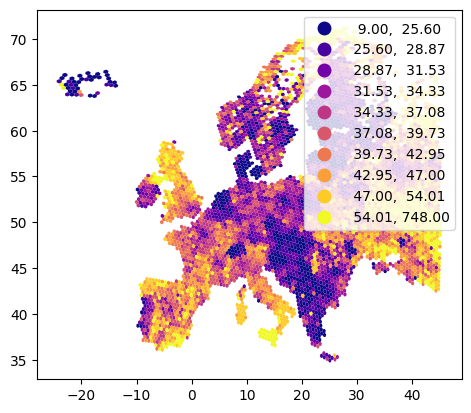

In [31]:
hex_gdf.plot(column="avg_lat_ms", cmap="plasma", markersize=1, scheme="Quantiles", k = 10, legend=True)

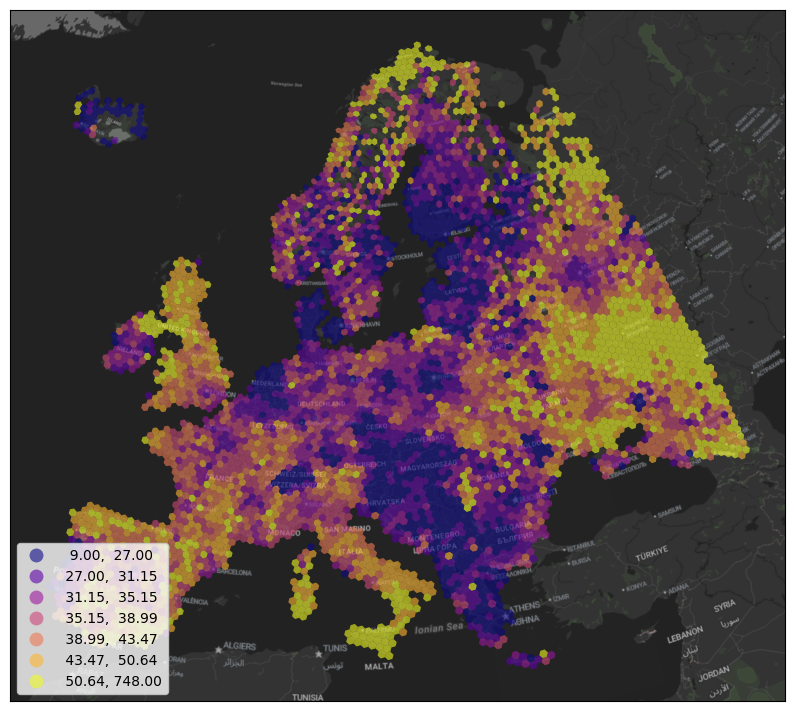

In [9]:
hex_gdf_projected = hex_gdf.to_crs("EPSG:3035")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
hex_gdf_projected.plot(ax = ax, alpha=0.6, column="avg_lat_ms", cmap="plasma", markersize=1, scheme="Quantiles", k = 7, legend=True,  legend_kwds={'loc': 'lower left'})
contextily.add_basemap(ax, source=stadia_url, crs=hex_gdf_projected.crs, zoom=5)

In [ ]:
stadia_api = "secret"

stadia_url = f"https://tiles.stadiamaps.com/tiles/alidade_smooth_dark/{{z}}/{{x}}/{{y}}.png?api_key={stadia_api}"

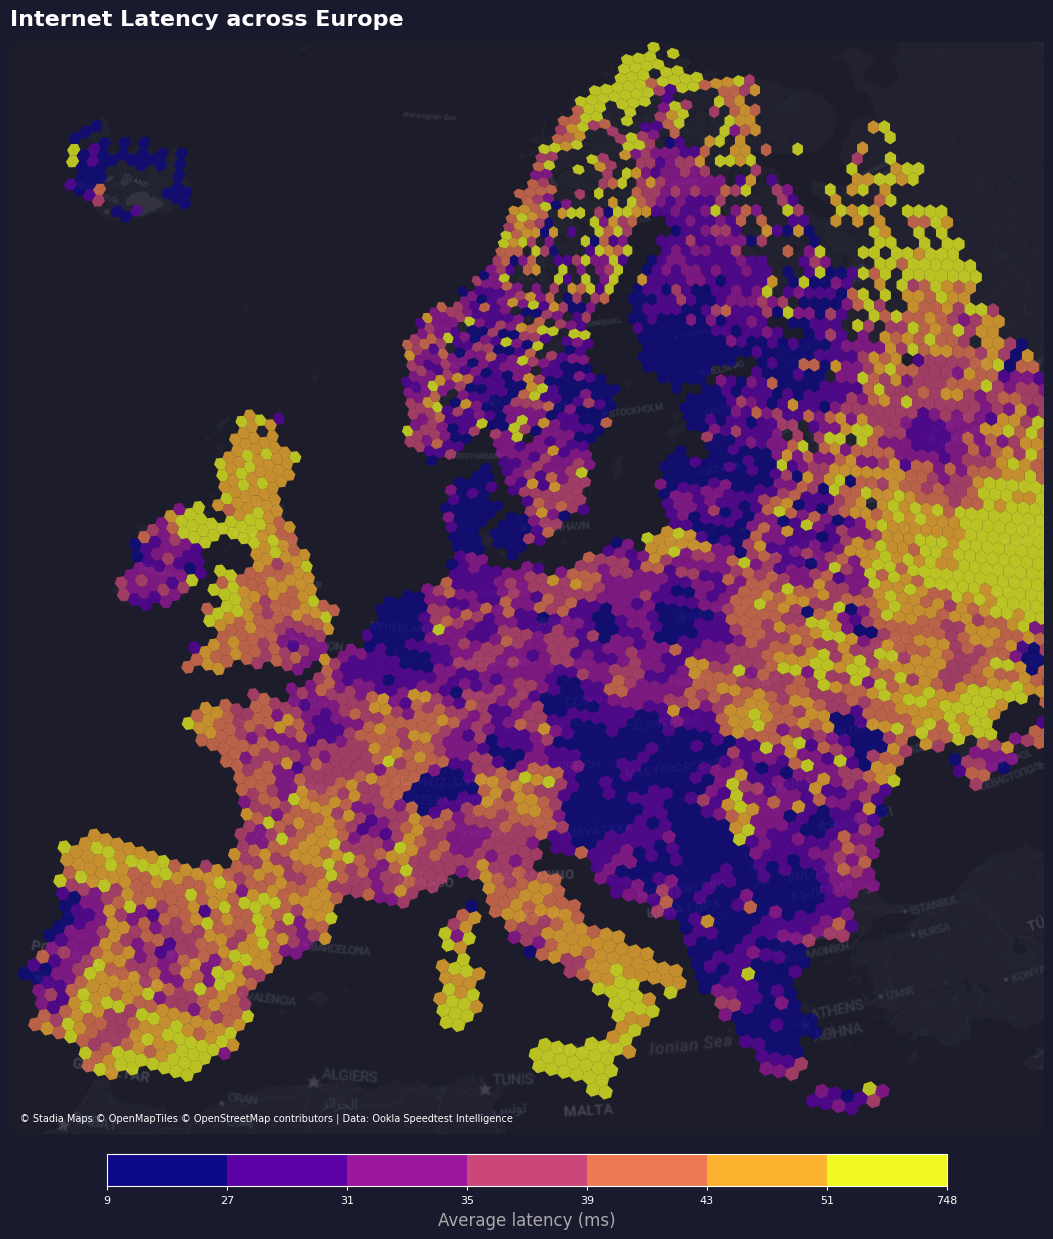

In [ ]:
fig = plt.figure(figsize=(12, 13), facecolor='#1a1a2e')

# Main map axis — leave room at bottom for legend
ax = fig.add_axes([0.02, 0.12, 0.96, 0.84])
ax.set_facecolor('#1a1a2e')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Plot hexagons — no built-in legend, we'll build our own
hex_gdf_projected.plot(
    ax=ax,
    alpha=0.75,
    column="avg_lat_ms",
    cmap="plasma",    
    scheme="Quantiles",
    k=7,
    legend=False,
    edgecolor='none',
    linewidth=0,
)

x1, x2 = ax.get_xlim()
y1, y2 = ax.get_ylim()

# Trim — adjust the fractions to taste
horizontal_trim = (x2 - x1) * 0.01  # 1% hor off each end
vertical_trim = (y2 - y1) * 0.01  # 1% vert off each end
ax.set_xlim(x1 + horizontal_trim * 4, x2 - horizontal_trim * 18)
ax.set_ylim(y1 + vertical_trim * 3, y2 - vertical_trim * 4.6)

contextily.add_basemap(
    ax,
    source=stadia_url,
    crs=hex_gdf_projected.crs,
    zoom=5,
    alpha=0.3
)

ax.set_title("Internet Latency across Europe", fontsize=16, fontweight='bold', color='white', pad=12, loc='left')
# --- Custom colorbar legend below the map ---
cax = fig.add_axes([0.15, 0.08, 0.70, 0.025])  # [left, bottom, width, height]

# Reproduce the quantile bin edges from the plot
from mapclassify import Quantiles
classifier = Quantiles(hex_gdf_projected["avg_lat_ms"].dropna(), k=7)
bins = np.concatenate([[hex_gdf_projected["avg_lat_ms"].min()], classifier.bins])

cmap = plt.cm.plasma
norm = mcolors.BoundaryNorm(bins, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_ticks(bins)
cbar.set_ticklabels([f"{v:.0f}" for v in bins], color='white', fontsize=8)
cbar.outline.set_edgecolor('white')
cbar.ax.tick_params(color='white', length=3)

ax.text(
    0.01, 0.01,
    "© Stadia Maps © OpenMapTiles © OpenStreetMap contributors | Data: Ookla Speedtest Intelligence",
    transform=ax.transAxes,
    fontsize=7,
    color='white',
    ha='left', va='bottom'
)

fig.text(0.5, 0.05, "Average latency (ms)", ha='center', fontsize=12, color='#aaaaaa')
# plt.savefig(MAP_DIRECTORY / "map4.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [101]:
hex_gdf_projected.head()

,hex_id,avg_lat_ms,geometry,q_class
0,8401201ffffffff,65.000000,"POLYGON ((4859658.955 5317253.119, 4877862.041...",0
1,8401205ffffffff,58.000000,"POLYGON ((4901950.648 5323021.674, 4920252.43 ...",0
2,8401207ffffffff,71.111111,"POLYGON ((4871984.739 5352074.343, 4890274.039...",0
3,8401209ffffffff,63.700000,"POLYGON ((4847414.798 5282647.437, 4865531.624...",0
4,840120dffffffff,62.500000,"POLYGON ((4889529.587 5288365.186, 4907745.306...",0


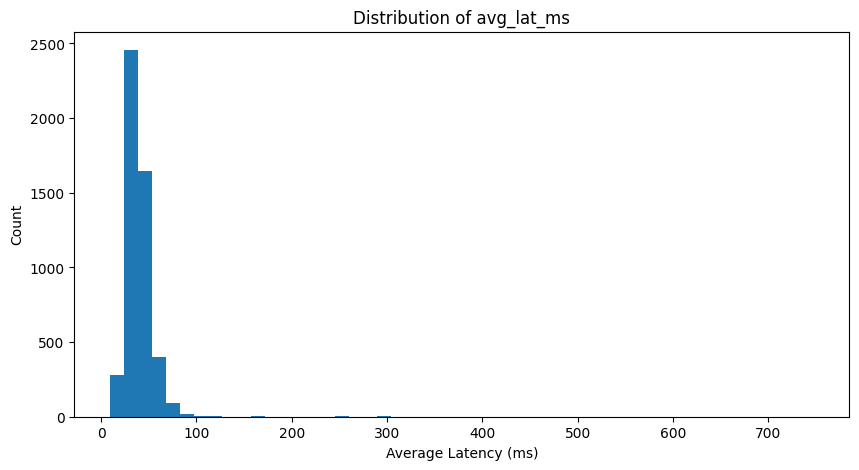

In [103]:

# Quick distribution plot for avg_lat_ms
fig, ax = plt.subplots(figsize=(10, 5))

hex_gdf_projected["avg_lat_ms"].plot(
    kind="hist",
    bins=50,
    ax=ax
)

ax.set_title("Distribution of avg_lat_ms")
ax.set_xlabel("Average Latency (ms)")
ax.set_ylabel("Count")

plt.show()

In [24]:
import geopandas as gpd
from shapely.ops import unary_union

# 1. Ensure valid geometries
europe_shapes = europe_shapes.copy()
europe_shapes["geometry"] = europe_shapes["geometry"].buffer(0)

# 2. Extract all country boundaries (includes coast + internal borders)
all_boundaries = europe_shapes.boundary.unary_union

# 3. Build full landmass (dissolve all countries into one shape)
land_union = unary_union(europe_shapes.geometry)

# 4. Extract ONLY the outer coastline of Europe
coastline = land_union.boundary

# 5. Internal borders = all borders minus coastline
internal_borders = all_boundaries.difference(coastline)

# 6. Convert to GeoDataFrame
land_borders_gdf = gpd.GeoDataFrame(
    geometry=[internal_borders],
    crs=europe_shapes.crs
)

# 7. Optional: explode into individual line segments
land_borders_gdf = land_borders_gdf.explode(index_parts=False)

/tmp/ipykernel_5375/2410078049.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  all_boundaries = europe_shapes.boundary.unary_union


<Axes: >

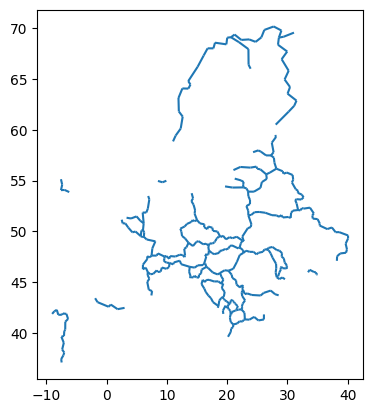

In [25]:
land_borders_gdf.plot()

<Axes: >

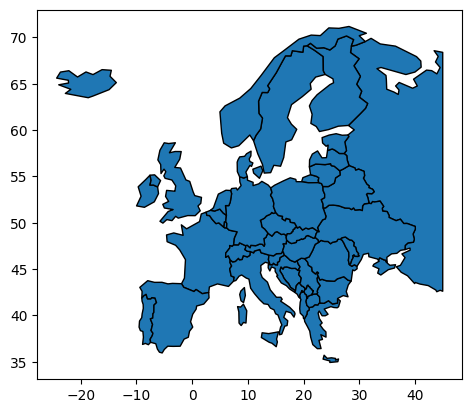

In [12]:
europe_shapes.plot(edgecolor="black")

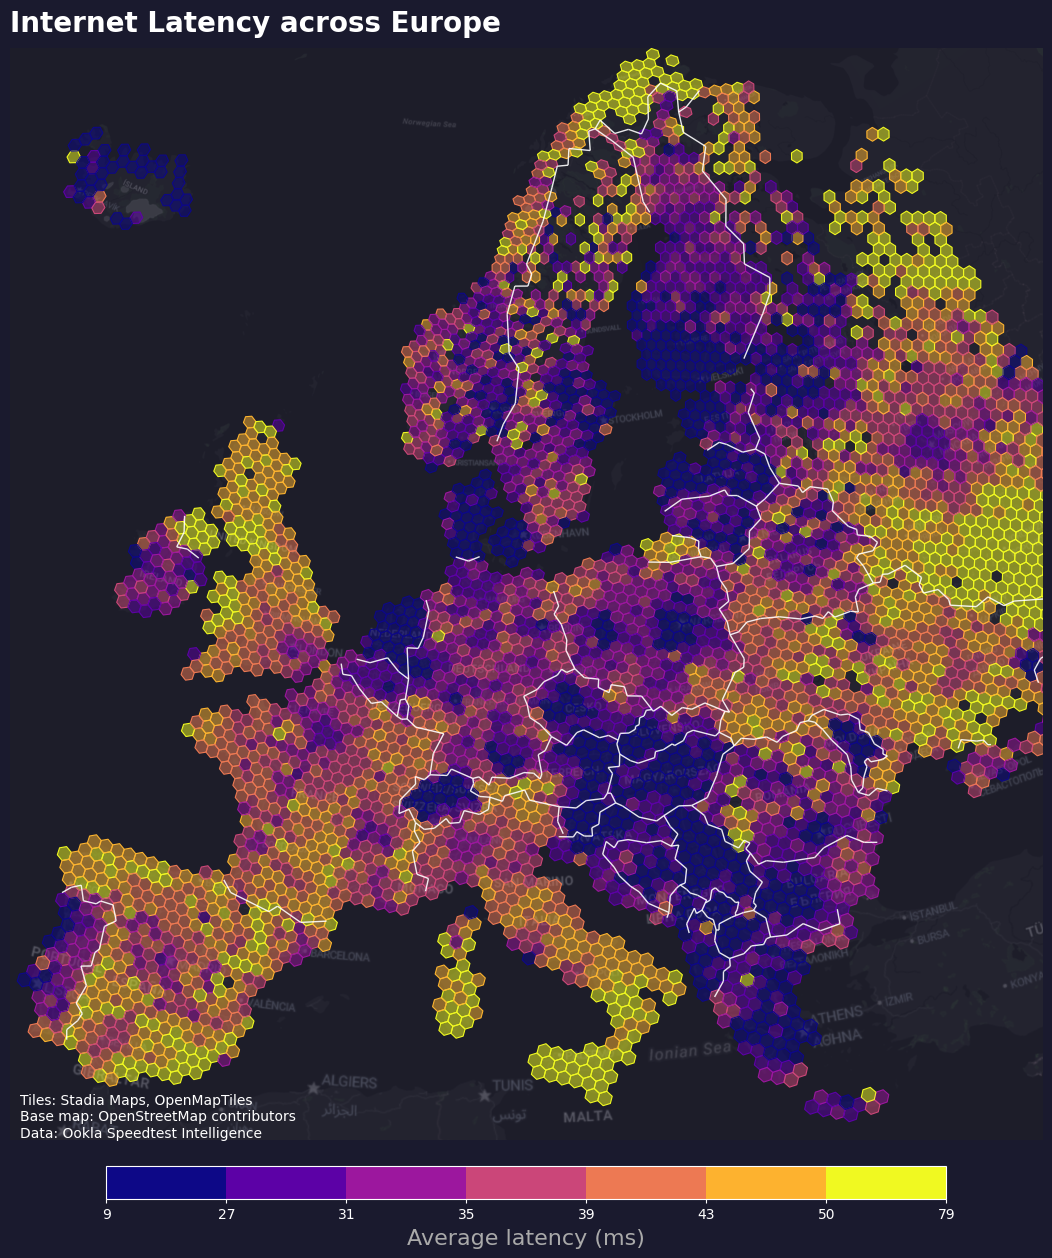

In [40]:
# Classify first
p99 = hex_gdf_projected["avg_lat_ms"].quantile(0.99)

filtered = hex_gdf_projected[
    hex_gdf_projected["avg_lat_ms"] <= p99
]
classifier = mapclassify.Quantiles(filtered["avg_lat_ms"].dropna(), k=7)
filtered["q_class"] = classifier.find_bin(filtered["avg_lat_ms"])

# Map each class to a plasma color
cmap = plt.cm.plasma
n_classes = 7
edge_colors = filtered["q_class"].apply(
    lambda x: cmap(x / (n_classes - 1))
)

fig = plt.figure(figsize=(12, 13), facecolor='#1a1a2e')

ax = fig.add_axes([0.02, 0.12, 0.96, 0.84])
ax.set_facecolor('#1a1a2e')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# PLOT STUFF
filtered.plot(ax=ax, facecolor=edge_colors, edgecolor='none', linewidth=0.8, alpha=0.5)
filtered.plot(ax=ax, facecolor='none', edgecolor=edge_colors, linewidth=0.8, alpha=1)
contextily.add_basemap(ax, source=stadia_url, crs=filtered.crs, zoom=5, alpha=0.4)
land_borders_gdf.to_crs(filtered.crs).plot(ax=ax, edgecolor='white', facecolor='none', linewidth=1, alpha=0.9)


x1, x2 = ax.get_xlim()
y1, y2 = ax.get_ylim()
horizontal_trim = (x2 - x1) * 0.01
vertical_trim = (y2 - y1) * 0.01
ax.set_xlim(x1 + horizontal_trim * 4, x2 - horizontal_trim * 18)
ax.set_ylim(y1 + vertical_trim * 3, y2 - vertical_trim * 4.5)

ax.set_title("Internet Latency across Europe", fontsize=20, fontweight='bold', color='white', pad=12, loc='left')

# Colorbar
cax = fig.add_axes([0.15, 0.075, 0.70, 0.025])
bins = np.concatenate([[filtered["avg_lat_ms"].min()], classifier.bins])
norm = mcolors.BoundaryNorm(bins, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_ticks(bins)
cbar.set_ticklabels([f"{v:.0f}" for v in bins], color='white', fontsize=10)
cbar.outline.set_edgecolor('white')
cbar.ax.tick_params(color='white', length=3)

ax.text(
    0.01, 0,
    "Tiles: Stadia Maps, OpenMapTiles\nBase map: OpenStreetMap contributors \nData: Ookla Speedtest Intelligence",
    transform=ax.transAxes,
    fontsize=10,
    color='white',
    ha='left', va='bottom'
)

fig.text(0.5, 0.04, "Average latency (ms)", ha='center', fontsize=16, color='#aaaaaa')

plt.savefig(MAP_DIRECTORY / "map11.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()